# Week 6 Interim Deliverable
## Baseline Logistic Regression Model

This notebook trains and evaluates a baseline Logistic Regression model to predict Emergency Severity Index (ESI) levels.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


## Load Dataset

In [2]:
# Dataset is directly loaded into Colab and displays the shape & column names
FILE_PATH = 'yaleemmlc_admissionprediction_triage.csv'
df = pd.read_csv(FILE_PATH)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn groups:")
print(f"  Chief complaint (cc_*) columns : {sum(1 for c in df.columns if c.startswith('cc_'))}")
print(f"  Vital sign columns              : {sum(1 for c in df.columns if 'vital' in c)}")
print(f"  Demographic columns             : approx. 10")

df.head(5)

Dataset loaded successfully.
Shape: 55,121 rows × 226 columns

Column groups:
  Chief complaint (cc_*) columns : 200
  Vital sign columns              : 7
  Demographic columns             : approx. 10


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Define Features and Target

In [3]:
features = [
    "triage_vital_o2",
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_rr",
    "triage_vital_temp",
    "age",
    "arrivalmode",
    "triage_glucose",
    "cc_dyspnea",
    "previousdispo"
]

X = df[features]
y = df["esi"]

## Train/Test Split
Random seed = **42**

In [4]:
RANDOM_STATE=42
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,stratify=y,random_state=RANDOM_STATE
)

## Preprocess and Train Logistic Regression

In [5]:
numeric_features=[
    "triage_vital_o2","triage_vital_hr","triage_vital_sbp",
    "triage_vital_rr","triage_vital_temp","age",
    "triage_glucose","cc_dyspnea"
]
categorical_features=["arrivalmode","previousdispo"]

preprocessor=ColumnTransformer([
    ("num",SimpleImputer(strategy="median"),numeric_features),
    ("cat",Pipeline([
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]),categorical_features)
])

model=Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(max_iter=1000,random_state=RANDOM_STATE))
])

model.fit(X_train,y_train)
y_pred=model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluation Metrics

In [6]:
print(classification_report(y_test,y_pred,digits=3))

              precision    recall  f1-score   support

         1.0      0.000     0.000     0.000        16
         2.0      0.574     0.411     0.479      3585
         3.0      0.520     0.806     0.632      5402
         4.0      0.440     0.021     0.040      1779
         5.0      0.000     0.000     0.000       243

    accuracy                          0.532     11025
   macro avg      0.307     0.248     0.230     11025
weighted avg      0.512     0.532     0.472     11025



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

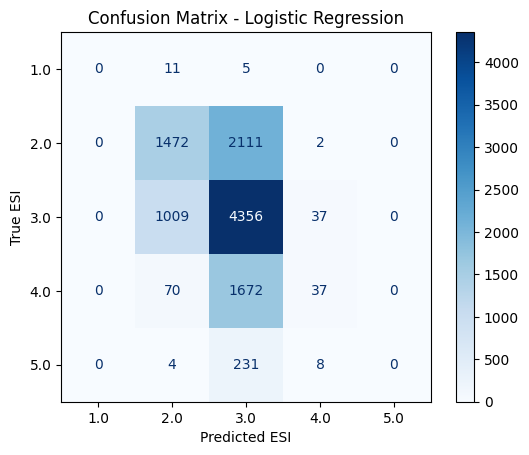

In [7]:
labels=sorted(y.unique())
cm=confusion_matrix(y_test,y_pred,labels=labels)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted ESI")
plt.ylabel("True ESI")
plt.show()

## Discussion

This notebook establishes a reproducible baseline Logistic Regression model using an 80/20 stratified train-test split (random seed = 42). Performance is evaluated using precision, recall, F1-score, and a confusion matrix for each ESI class.